# Анализ тональности отзывов клиентов (Yelp Review Full)

**Датасет:** `Yelp/yelp_review_full` — 650k отзывов, 3 класса (негатив / нейтраль / позитив)  
**Задача:** 3-классовая классификация тональности  
**Модели:** Logistic Regression, SVM, BiLSTM, DistilBERT, LiYuan (Amazon BERT)

## 1. Установка зависимостей

In [ ]:
%%capture
!pip install datasets transformers torch torchvision torchaudio --quiet
!pip install nltk wordcloud scikit-learn seaborn matplotlib tqdm --quiet
!pip install accelerate --quiet


In [ ]:
import os
import re
import time
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter

warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F

# Transformers
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)

# WordCloud
from wordcloud import WordCloud

# HuggingFace Datasets
from datasets import load_dataset

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


Устройство: cuda
GPU: Tesla T4


## 2. Загрузка датасета

In [ ]:
dataset = load_dataset("Yelp/yelp_review_full")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})


In [ ]:
TRAIN_SIZE = 50_000
TEST_SIZE  = 10_000

train_df = pd.DataFrame(dataset['train']).groupby('label', group_keys=False)\
           .apply(lambda x: x.sample(TRAIN_SIZE // 5, random_state=SEED)).reset_index(drop=True)
test_df  = pd.DataFrame(dataset['test']).groupby('label', group_keys=False)\
           .apply(lambda x: x.sample(TEST_SIZE // 5, random_state=SEED)).reset_index(drop=True)

train_df['stars'] = train_df['label'] + 1
test_df['stars']  = test_df['label']  + 1

def map3(label):
    if label <= 1: return 0
    if label == 2: return 1
    return 2

train_df['label'] = train_df['label'].map(map3)
test_df['label']  = test_df['label'].map(map3)

print(f'Train: {len(train_df):,}')
print(f'Test:  {len(test_df):,}')
print('\nРаспределение классов (train):')
print(train_df['label'].value_counts().sort_index()
      .rename({0:'негатив (1-2)', 1:'удовлетворительно (3)', 2:'позитив (4-5)'}))
train_df.head(3)


Train: 50,000
Test:  10,000

Распределение классов (train):
label
негатив (1-2)            20000
удовлетворительно (3)    10000
позитив (4-5)            20000
Name: count, dtype: int64


,label,text,stars
0,0,It was my first time boarding my dogs of 6yrs....,1
1,0,terrible service! the only advantage of this ...,1
2,0,staff is friendly enough..drs are quick and do...,1


## 3. Разведочный анализ данных (EDA)

In [ ]:
print(f'Колонки: {list(train_df.columns)}')
print(f'Нулевые значения:\n{train_df.isnull().sum()}')
print(f'\nРаспределение классов:')
print(train_df['label'].value_counts().sort_index()
      .rename({0:'негатив', 1:'удовлетворительно', 2:'позитив'}))


Колонки: ['label', 'text', 'stars']
Нулевые значения:
label    0
text     0
stars    0
dtype: int64

Распределение классов:
label
негатив              20000
удовлетворительно    10000
позитив              20000
Name: count, dtype: int64


In [ ]:
train_df['text_len']     = train_df['text'].str.len()
train_df['word_count']   = train_df['text'].str.split().str.len()
train_df['unique_words'] = train_df['text'].str.lower().str.split().apply(lambda x: len(set(x)))
print(train_df[['text_len','word_count','unique_words']].describe().round(1))


       text_len  word_count  unique_words
count   50000.0     50000.0       50000.0
mean      735.3       134.6          90.5
std       662.0       121.1          65.0
min         2.0         1.0           1.0
25%       289.0        53.0          44.0
50%       541.0       100.0          75.0
75%       964.0       176.0         120.0
max      5057.0       991.0         487.0


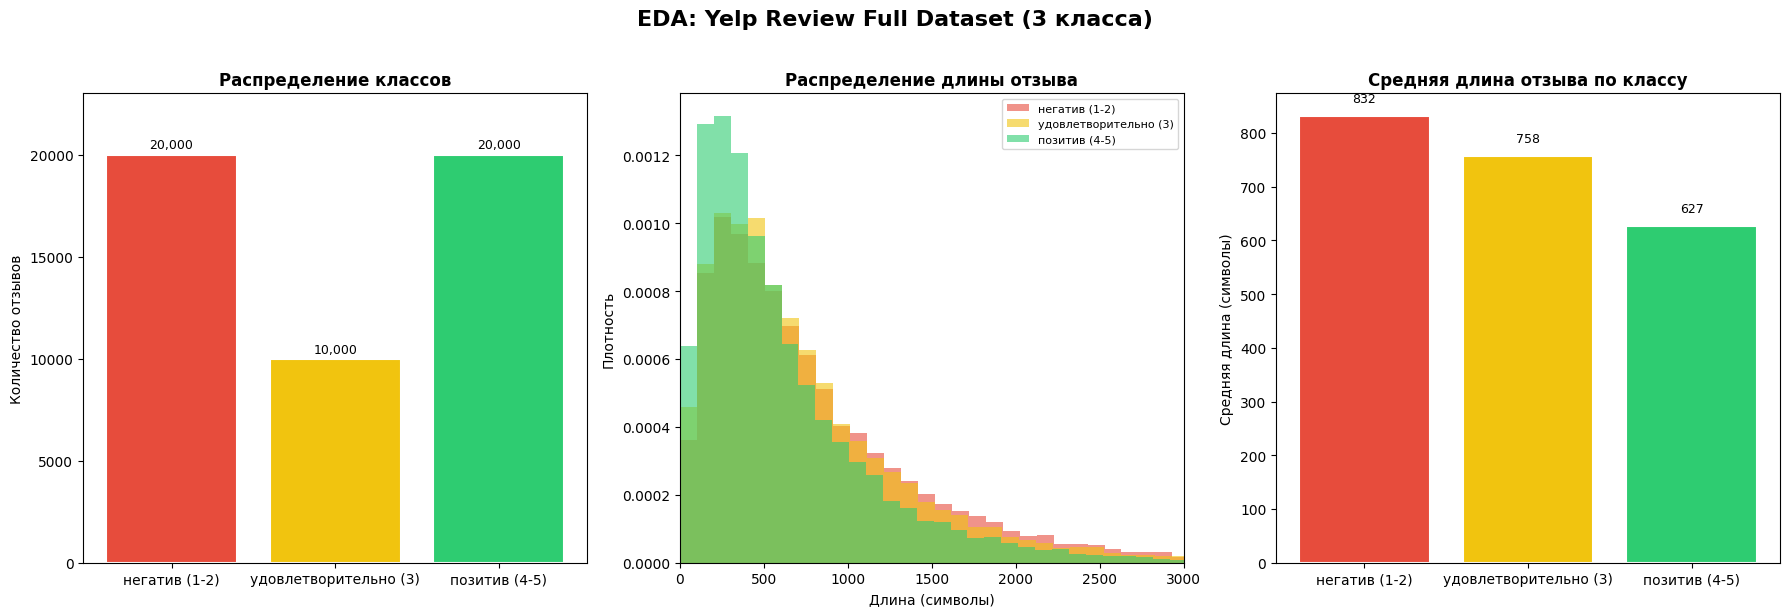

In [ ]:
COLORS = ['#e74c3c', '#f1c40f', '#2ecc71']
LABELS = ['негатив (1-2)', 'удовлетворительно (3)', 'позитив (4-5)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('EDA: Yelp Review Full Dataset (3 класса)', fontsize=16, fontweight='bold', y=1.02)

ax = axes[0]
counts = train_df['label'].value_counts().sort_index()
bars = ax.bar(LABELS, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax.set_title('Распределение классов', fontweight='bold')
ax.set_ylabel('Количество отзывов')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
            f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, counts.max()*1.15)

ax = axes[1]
for lbl, color, name in zip([0,1,2], COLORS, LABELS):
    data = train_df[train_df['label']==lbl]['text_len']
    ax.hist(data, bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Распределение длины отзыва', fontweight='bold')
ax.set_xlabel('Длина (символы)')
ax.set_ylabel('Плотность')
ax.set_xlim(0, 3000)
ax.legend(fontsize=8)

ax = axes[2]
mean_len = train_df.groupby('label')['text_len'].mean()
ax.bar(LABELS, mean_len.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax.set_title('Средняя длина отзыва по классу', fontweight='bold')
ax.set_ylabel('Средняя длина (символы)')
for i, v in enumerate(mean_len.values):
    ax.text(i, v+20, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_main.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Предобработка текста

In [ ]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\\n|\n', ' ', text)
    text = re.sub(r"[^a-z\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

tqdm.pandas(desc="Train")
train_df['clean_text'] = train_df['text'].progress_apply(clean_text)

tqdm.pandas(desc="Test")
test_df['clean_text'] = test_df['text'].progress_apply(clean_text)

print("Пример:")
print("ОРИГИНАЛ:", train_df['text'].iloc[0][:200])
print("ОЧИЩЕННЫЙ:", train_df['clean_text'].iloc[0][:200])


Train:   0%|          | 0/50000 [00:00<?, ?it/s]

Test:   0%|          | 0/10000 [00:00<?, ?it/s]

Пример:
ОРИГИНАЛ: It was my first time boarding my dogs of 6yrs. I was very nervous and saw that they have great reviews but I was unsure. The staff seemed very pleasant.  I came to drop my dogs off and asked to see wh
ОЧИЩЕННЫЙ: first time boarding dog yr nervous saw great review unsure staff seemed pleasant came drop dog asked see would kept met bit hesitation despite option took back bahamas room said put uncomfortable walk


In [ ]:
X = train_df['clean_text'].values
y = train_df['label'].values  # 0, 1, 2

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_test = test_df['clean_text'].values
y_test = test_df['label'].values

raw_idx_train, raw_idx_val = train_test_split(
    np.arange(len(train_df)), test_size=0.2, random_state=SEED, stratify=y
)
X_train_raw = train_df['text'].values[raw_idx_train]
X_val_raw   = train_df['text'].values[raw_idx_val]
X_test_raw  = test_df['text'].values

print(f'Train: {len(X_train):,}')
print(f'Val:   {len(X_val):,}')
print(f'Test:  {len(X_test):,}')


Train: 40,000
Val:   10,000
Test:  10,000


## 5. Векторизация TF-IDF и отбор признаков

In [ ]:
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)

X_train_tfidf_raw = tfidf.fit_transform(X_train)
X_val_tfidf_raw   = tfidf.transform(X_val)
X_test_tfidf_raw  = tfidf.transform(X_test)


selector = SelectKBest(chi2, k=15_000)
X_train_tfidf = selector.fit_transform(X_train_tfidf_raw, y_train)
X_val_tfidf   = selector.transform(X_val_tfidf_raw)
X_test_tfidf  = selector.transform(X_test_tfidf_raw)

print(f"TF-IDF + chi2: {X_train_tfidf.shape}")

TF-IDF + chi2: (40000, 15000)


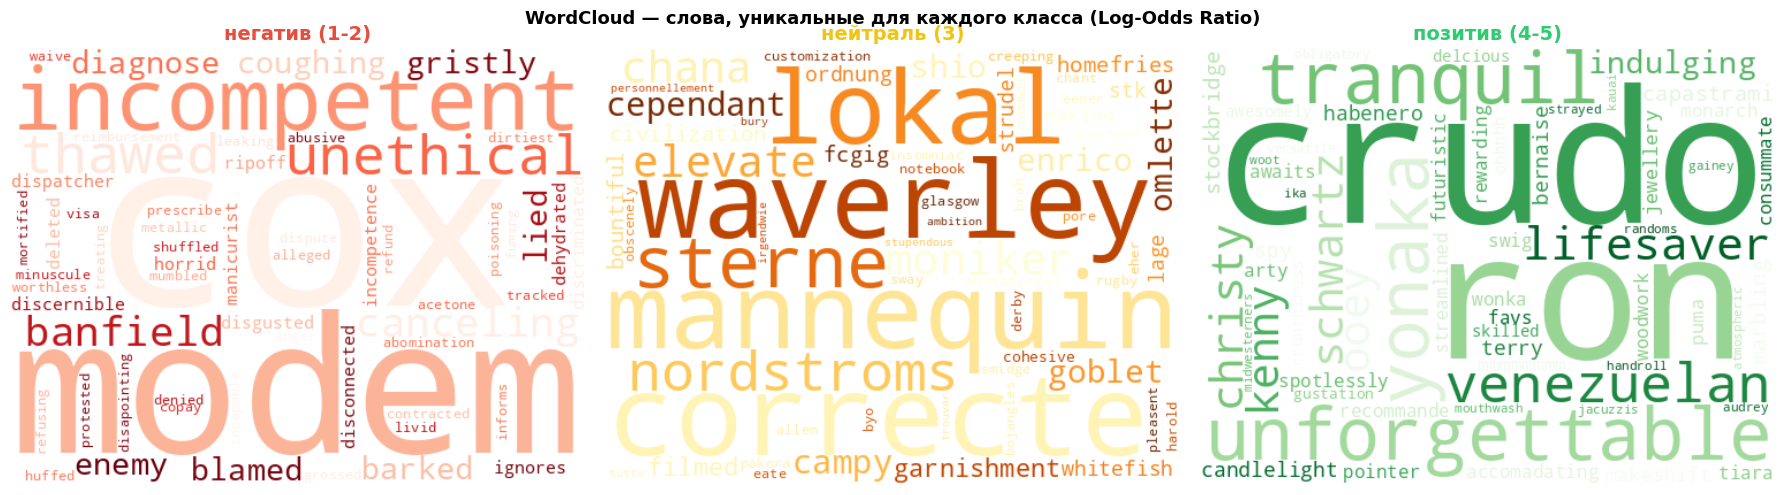

In [ ]:
def get_class_distinctive_words(train_texts, train_labels, target_class, top_n=100):
    cv = CountVectorizer(max_features=20000, min_df=5)
    X_counts = cv.fit_transform(train_texts)
    vocab    = cv.get_feature_names_out()
    mask_pos = train_labels == target_class
    mask_neg = ~mask_pos
    count_pos = np.asarray(X_counts[mask_pos].sum(axis=0)).flatten() + 1
    count_neg = np.asarray(X_counts[mask_neg].sum(axis=0)).flatten() + 1
    freq_pos  = count_pos / count_pos.sum()
    freq_neg  = count_neg / count_neg.sum()
    log_odds  = np.log(freq_pos / freq_neg)
    top_idx   = np.argsort(log_odds)[-top_n:]
    return {vocab[i]: float(log_odds[i]) for i in top_idx if log_odds[i] > 0}

CMAPS = ['Reds', 'YlOrBr', 'Greens']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WordCloud — слова, уникальные для каждого класса (Log-Odds Ratio)',
             fontsize=13, fontweight='bold')

for cls_idx, (ax, cmap, name) in enumerate(zip(axes, CMAPS, LABELS)):
    word_scores = get_class_distinctive_words(X_train, y_train, target_class=cls_idx)
    if word_scores:
        wc = WordCloud(width=500, height=380, background_color='white',
                       max_words=60, colormap=cmap, prefer_horizontal=0.8,
                       relative_scaling=0.6).generate_from_frequencies(word_scores)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(name, fontsize=14, fontweight='bold', color=COLORS[cls_idx])

plt.tight_layout()
plt.savefig('wordclouds_logodds.png', dpi=120, bbox_inches='tight')
plt.show()


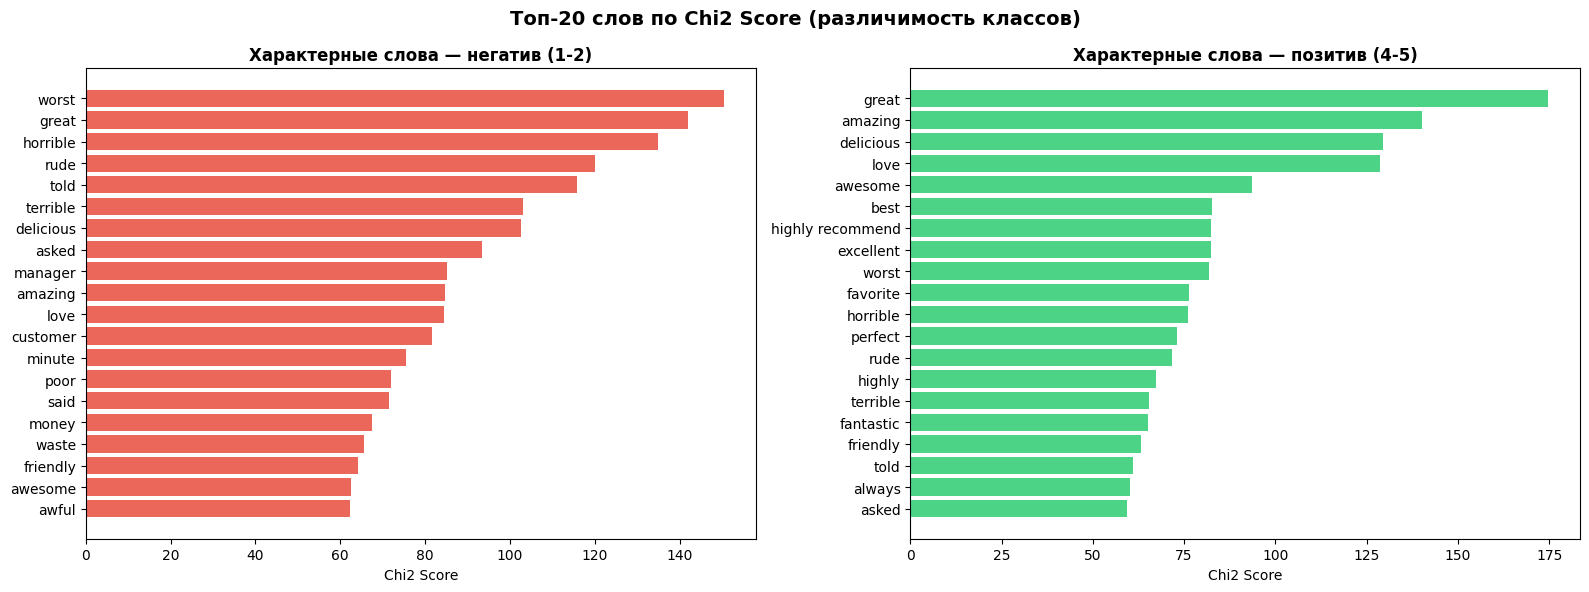

In [ ]:
def get_top_chi2_words(X_tfidf_raw, y, target_class, top_n=20):
    y_bin = (y == target_class).astype(int)
    scores, _ = chi2(X_tfidf_raw, y_bin)
    feature_names = tfidf.get_feature_names_out()
    top_idx = np.argsort(scores)[-top_n:][::-1]
    return [(feature_names[i], scores[i]) for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Топ-20 слов по Chi2 Score (различимость классов)', fontsize=14, fontweight='bold')

top_neg = get_top_chi2_words(X_train_tfidf_raw, y_train, target_class=0)
words_n, scores_n = zip(*top_neg)
axes[0].barh(words_n, scores_n, color='#e74c3c', alpha=0.85)
axes[0].set_title('Характерные слова — негатив (1-2)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Chi2 Score')

top_pos = get_top_chi2_words(X_train_tfidf_raw, y_train, target_class=2)
words_p, scores_p = zip(*top_pos)
axes[1].barh(words_p, scores_p, color='#2ecc71', alpha=0.85)
axes[1].set_title('Характерные слова — позитив (4-5)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('Chi2 Score')

plt.tight_layout()
plt.savefig('chi2_words.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Вспомогательные функции оценки

In [ ]:
CLASS_NAMES = ['негатив (1-2)', 'нейтраль (3)', 'позитив (4-5)']
COLORS      = ['#e74c3c', '#f1c40f', '#2ecc71']

results_table = {}

def sentiment_consistency_score(y_true, y_pred):
    errors = np.abs(np.array(y_true) - np.array(y_pred))
    return 1 - errors.mean() / 2

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ['Абсолютная', 'Нормализованная'], ['d', '.2f']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    ax=ax, linewidths=0.5)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Предсказано')
        ax.set_ylabel('Истинно')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_proba, model_name):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc = roc_auc_score(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, color=color, label=f'{cls} (AUC={auc:.3f})', linewidth=2)
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curves (One-vs-Rest) — {model_name}', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'roc_{model_name.replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()

def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro')
    f1w  = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    scs  = sentiment_consistency_score(y_true, y_pred)
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'  Accuracy:    {acc:.4f}')
    print(f'  F1 Macro:    {f1m:.4f}')
    print(f'  F1 Weighted: {f1w:.4f}')
    print(f'  Precision:   {prec:.4f}')
    print(f'  Recall:      {rec:.4f}')
    print(f'  SCS:         {scs:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    results_table[model_name] = {
        'Accuracy': acc, 'Precision (macro)': prec, 'Recall (macro)': rec,
        'F1 Macro': f1m, 'F1 Weighted': f1w, 'SCS': scs
    }
    plot_confusion_matrix(y_true, y_pred, model_name)
    if y_pred_proba is not None:
        plot_roc_curves(y_true, y_pred_proba, model_name)
    return acc, f1m, scs

def plot_learning_curves_dl(history, model_name):
    epochs_range = range(1, len(history['train_loss'])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Кривые обучения — {model_name}', fontsize=13, fontweight='bold')
    ax1.plot(epochs_range, history['train_loss'], 'o-', color='#3498db', label='Train Loss', linewidth=2)
    ax1.plot(epochs_range, history['val_loss'],   's-', color='#e74c3c', label='Val Loss',   linewidth=2)
    best_ep = np.argmin(history['val_loss']) + 1
    ax1.axvline(best_ep, linestyle='--', color='gray', alpha=0.6, label=f'Best epoch={best_ep}')
    ax1.set_title('Loss'); ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs_range, history['train_acc'], 'o-', color='#3498db', label='Train Acc', linewidth=2)
    ax2.plot(epochs_range, history['val_acc'],   's-', color='#e74c3c', label='Val Acc',   linewidth=2)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'lc_{model_name.replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()

## 7. Модель 1: Logistic Regression

   Параметры: C=0.3, L1 (Lasso) — обнуляет нерелевантные фичи
Обучено за 4.9 сек
   Ненулевых весов: 686 из 45000

  Logistic Regression
  Accuracy:    0.7391
  F1 Macro:    0.6606
  F1 Weighted: 0.7177
  Precision:   0.6936
  Recall:      0.6628
  SCS:         0.8327

  Classification Report:
               precision    recall  f1-score   support

негатив (1-2)       0.76      0.86      0.81      4000
 нейтраль (3)       0.56      0.28      0.38      2000
позитив (4-5)       0.76      0.85      0.80      4000

     accuracy                           0.74     10000
    macro avg       0.69      0.66      0.66     10000
 weighted avg       0.72      0.74      0.72     10000



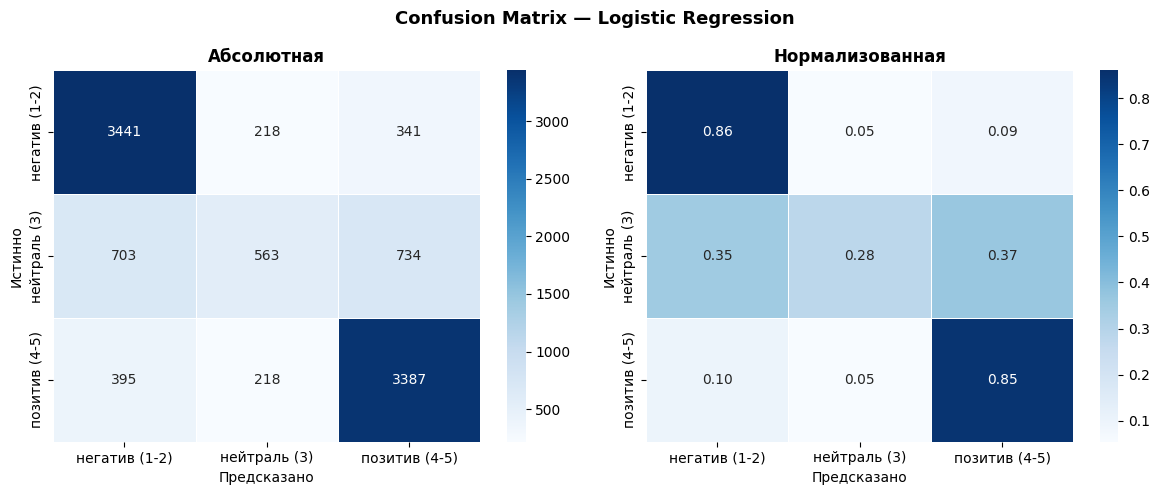

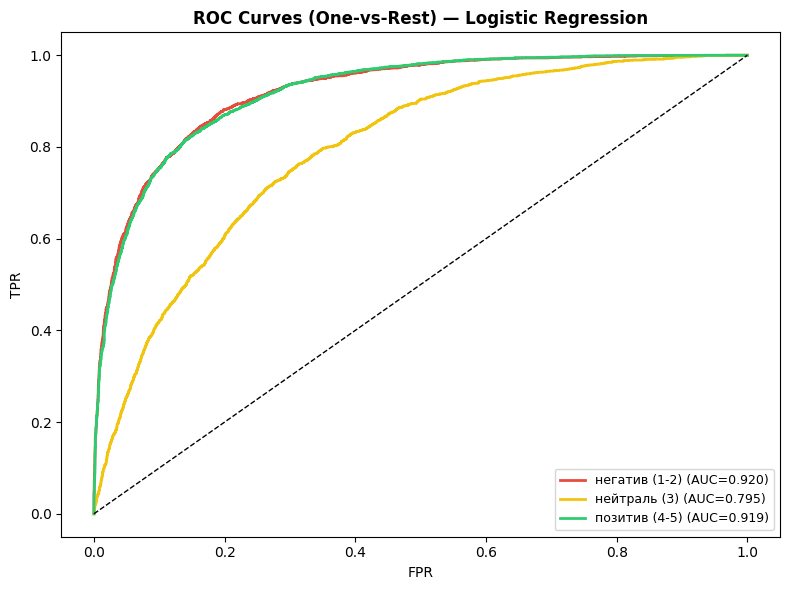

In [ ]:
print("   Параметры: C=0.3, L1 (Lasso) — обнуляет нерелевантные фичи")
t0 = time.time()


lr_model = LogisticRegression(
    C=0.3,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    max_iter=1000,
    n_jobs=-1,
    random_state=SEED,
    tol=1e-3
)
lr_model.fit(X_train_tfidf, y_train)

lr_time = time.time() - t0
print(f"Обучено за {lr_time:.1f} сек")
print(f"   Ненулевых весов: {(lr_model.coef_ != 0).sum()} из {lr_model.coef_.size}")

y_pred_lr  = lr_model.predict(X_test_tfidf)
y_proba_lr = lr_model.predict_proba(X_test_tfidf)

acc_lr, f1_lr, scs_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
results_table["Logistic Regression"]["Train Time (s)"] = round(lr_time, 1)

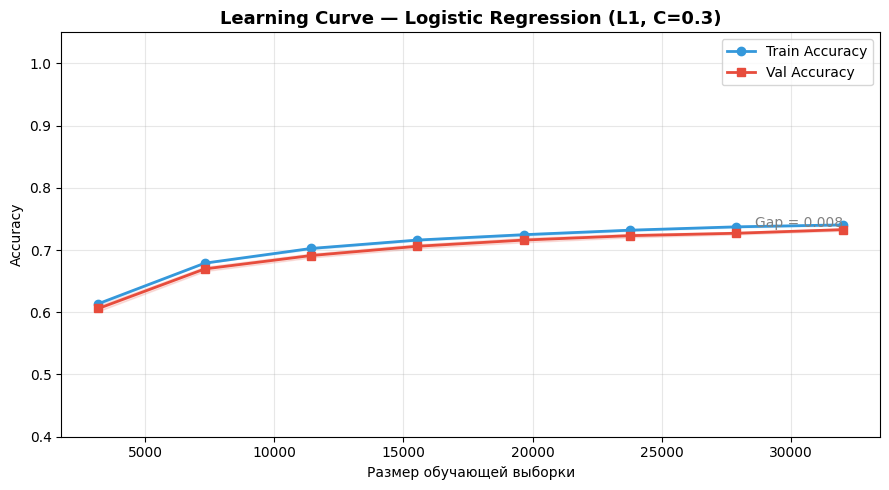

Gap train/val: 0.008 — OK


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=0.3, penalty='l1', solver='saga',
                       multi_class='multinomial', max_iter=500,
                       n_jobs=-1, random_state=SEED, tol=1e-3),
    X_train_tfidf, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
train_mean = train_scores.mean(axis=1); train_std = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1);   val_std   = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Train Accuracy', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 's-', color='#e74c3c', label='Val Accuracy', linewidth=2)
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#e74c3c')

gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap = {gap:.3f}', xy=(train_sizes[-1], (train_mean[-1]+val_mean[-1])/2),
            fontsize=10, color='gray', ha='right')
ax.set_title('Learning Curve — Logistic Regression (L1, C=0.3)', fontweight='bold', fontsize=13)
ax.set_xlabel('Размер обучающей выборки'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(0.4, 1.05)
plt.tight_layout(); plt.savefig('lc_LR.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"Gap train/val: {gap:.3f} — {'OK' if gap < 0.1 else 'Есть разрыв' if gap < 0.2 else 'Переобучение'}")

## 8. Модель 2: SVM (LinearSVC)

   Параметры: C=0.1, dual=False, squared_hinge
Обучено за 4.8 сек

  SVM (LinearSVC)
  Accuracy:    0.7630
  F1 Macro:    0.6886
  F1 Weighted: 0.7449
  Precision:   0.7129
  Recall:      0.6892
  SCS:         0.8561

  Classification Report:
               precision    recall  f1-score   support

негатив (1-2)       0.79      0.88      0.83      4000
 нейтраль (3)       0.56      0.32      0.41      2000
позитив (4-5)       0.79      0.87      0.83      4000

     accuracy                           0.76     10000
    macro avg       0.71      0.69      0.69     10000
 weighted avg       0.74      0.76      0.74     10000



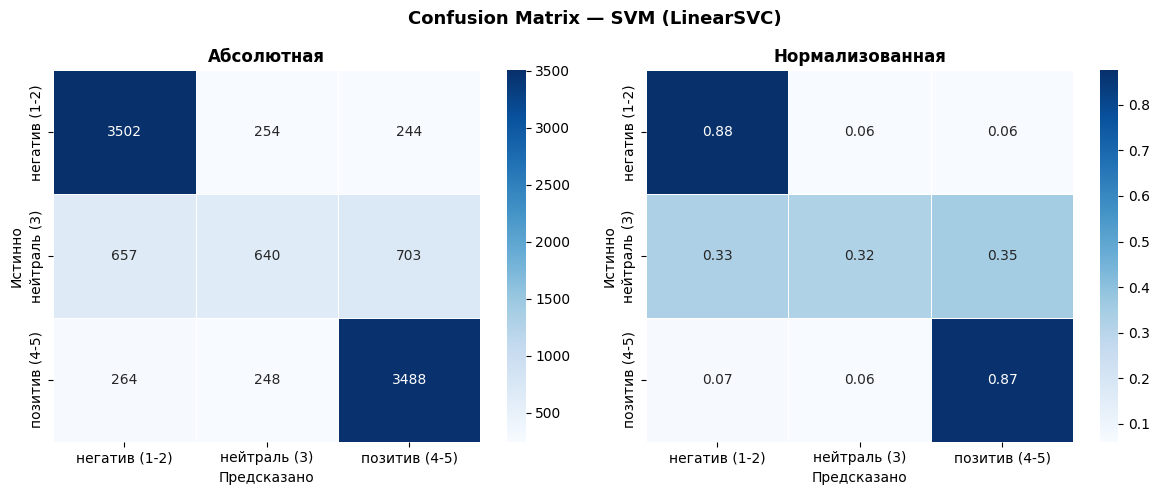

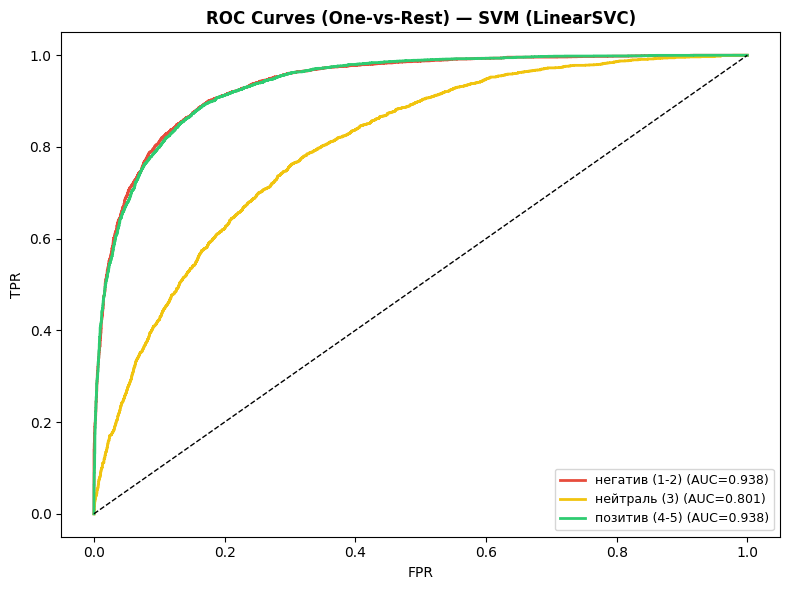

In [ ]:
print("   Параметры: C=0.1, dual=False, squared_hinge")
t0 = time.time()

svm_base = LinearSVC(
    C=0.1,
    max_iter=3000,
    dual=False,
    loss='squared_hinge',
    random_state=SEED,
    tol=1e-4
)
svm_base.fit(X_train_tfidf, y_train)

svm_model = CalibratedClassifierCV(svm_base, cv='prefit')
svm_model.fit(X_val_tfidf, y_val)

svm_time = time.time() - t0
print(f"Обучено за {svm_time:.1f} сек")

y_pred_svm  = svm_model.predict(X_test_tfidf)
y_proba_svm = svm_model.predict_proba(X_test_tfidf)

acc_svm, f1_svm, scs_svm = evaluate_model("SVM (LinearSVC)", y_test, y_pred_svm, y_proba_svm)
results_table["SVM (LinearSVC)"]["Train Time (s)"] = round(svm_time, 1)

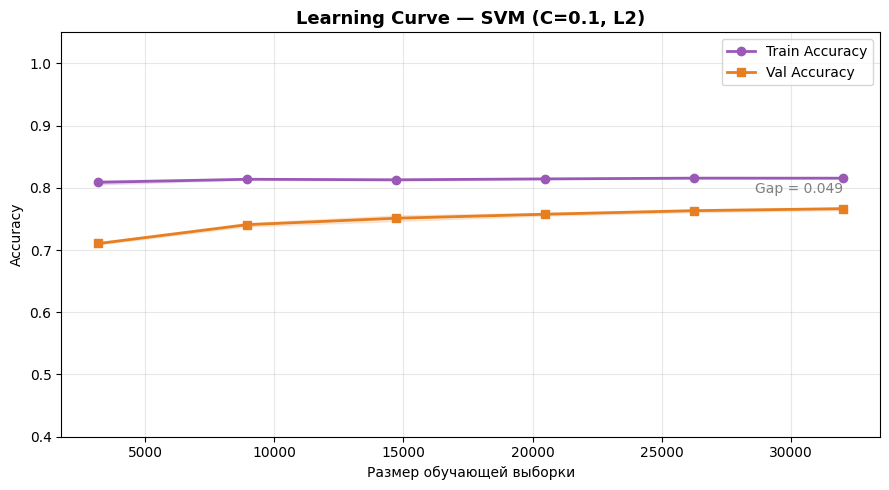

Gap train/val: 0.049 — OK


In [ ]:
train_sizes_s, train_scores_s, val_scores_s = learning_curve(
    LinearSVC(C=0.1, max_iter=2000, dual=False,
              loss='squared_hinge', random_state=SEED),
    X_train_tfidf, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
t_mean = train_scores_s.mean(axis=1); t_std = train_scores_s.std(axis=1)
v_mean = val_scores_s.mean(axis=1);   v_std = val_scores_s.std(axis=1)

ax.plot(train_sizes_s, t_mean, 'o-', color='#9b59b6', label='Train Accuracy', linewidth=2)
ax.fill_between(train_sizes_s, t_mean-t_std, t_mean+t_std, alpha=0.15, color='#9b59b6')
ax.plot(train_sizes_s, v_mean, 's-', color='#e67e22', label='Val Accuracy', linewidth=2)
ax.fill_between(train_sizes_s, v_mean-v_std, v_mean+v_std, alpha=0.15, color='#e67e22')

gap = t_mean[-1] - v_mean[-1]
ax.annotate(f'Gap = {gap:.3f}', xy=(train_sizes_s[-1], (t_mean[-1]+v_mean[-1])/2),
            fontsize=10, color='gray', ha='right')
ax.set_title('Learning Curve — SVM (C=0.1, L2)', fontweight='bold', fontsize=13)
ax.set_xlabel('Размер обучающей выборки'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(0.4, 1.05)
plt.tight_layout(); plt.savefig('lc_SVM.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"Gap train/val: {gap:.3f} — {'OK' if gap < 0.1 else 'Есть разрыв' if gap < 0.2 else 'Переобучение'}")

## 9. Модель 3: Bidirectional LSTM

In [ ]:
MAX_VOCAB = 30_000
MAX_LEN   = 200

counter = Counter()
for text in tqdm(X_train, desc="Vocab"):
    counter.update(text.split())

vocab = ['<PAD>', '<UNK>'] + [w for w, c in counter.most_common(MAX_VOCAB-2)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f"Размер словаря: {VOCAB_SIZE:,}")

def encode(texts, max_len=MAX_LEN):
    encoded = []
    for text in texts:
        tokens = text.split()[:max_len]
        ids = [word2idx.get(t, 1) for t in tokens]
        ids = ids + [0] * (max_len - len(ids))
        encoded.append(ids)
    return np.array(encoded, dtype=np.int64)

X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)
print(f"Форма: {X_train_enc.shape}")


Vocab:   0%|          | 0/40000 [00:00<?, ?it/s]

Размер словаря: 30,000
Форма: (40000, 200)


In [ ]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_ds = TextDataset(X_train_enc, y_train)
val_ds   = TextDataset(X_val_enc,   y_val)
test_ds  = TextDataset(X_test_enc,  y_test)

train_loader_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Батчей в train: {len(train_loader_dl)}")

Батчей в train: 313


In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, n_classes=5, dropout=0.5):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop  = nn.Dropout(dropout)
        self.lstm        = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                   bidirectional=True, batch_first=True,
                                   dropout=dropout)
        self.attn        = nn.Linear(hidden_dim * 2, 1)
        self.layer_norm  = nn.LayerNorm(hidden_dim * 2)
        self.dropout     = nn.Dropout(dropout)
        self.fc1         = nn.Linear(hidden_dim * 2, 128)
        self.fc2         = nn.Linear(128, n_classes)
        self.relu        = nn.ReLU()

    def forward(self, x):
        emb = self.embed_drop(self.embedding(x))
        out, _ = self.lstm(emb)
        attn_w = torch.softmax(self.attn(out), dim=1)
        context = (attn_w * out).sum(dim=1)

        context = self.layer_norm(context)
        context = self.dropout(context)
        out = self.relu(self.fc1(context))
        out = self.dropout(out)
        return self.fc2(out)

In [ ]:
def train_dl_model(model, train_loader, val_loader, model_name,
                   epochs=12, patience=3, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')
    best_weights  = None
    no_improve    = 0
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} TRAIN",
                    leave=False, ncols=100)
        for X_batch, y_batch in pbar:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss    += loss.item() * y_batch.size(0)
            preds          = logits.argmax(dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total   += y_batch.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_loader, desc=f"  VAL", leave=False, ncols=100):
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits   = model(X_batch)
                loss     = criterion(logits, y_batch)
                val_loss += loss.item() * y_batch.size(0)
                preds     = logits.argmax(dim=1)
                val_correct += (preds == y_batch).sum().item()
                val_total   += y_batch.size(0)

        t_loss = train_loss / train_total
        v_loss = val_loss   / val_total
        t_acc  = train_correct / train_total
        v_acc  = val_correct   / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        scheduler.step(v_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Ранняя остановка на эпохе {epoch+1}")
                break

    total_time = time.time() - t_start
    print(f"\nОбучение завершено за {total_time:.1f} сек")

    model.load_state_dict(best_weights)
    return model, history, total_time

def predict_dl(model, loader):
    model.eval()
    all_preds, all_proba = [], []
    with torch.no_grad():
        for X_batch, _ in tqdm(loader, desc="Предсказание", ncols=80):
            X_batch = X_batch.to(DEVICE)
            logits  = model(X_batch)
            proba   = torch.softmax(logits, dim=1).cpu().numpy()
            preds   = proba.argmax(axis=1)
            all_preds.extend(preds)
            all_proba.extend(proba)
    return np.array(all_preds), np.array(all_proba)

def plot_learning_curves_dl(history, model_name):
    epochs_range = range(1, len(history['train_loss'])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Кривые обучения — {model_name}', fontsize=13, fontweight='bold')

    ax1.plot(epochs_range, history['train_loss'], 'o-', color='#3498db', label='Train Loss', linewidth=2)
    ax1.plot(epochs_range, history['val_loss'],   's-', color='#e74c3c', label='Val Loss',   linewidth=2)
    ax1.set_title('Loss'); ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    best_ep = np.argmin(history['val_loss']) + 1
    ax1.axvline(best_ep, linestyle='--', color='gray', alpha=0.6, label=f'Best epoch={best_ep}')
    ax1.legend()

    ax2.plot(epochs_range, history['train_acc'], 'o-', color='#3498db', label='Train Acc', linewidth=2)
    ax2.plot(epochs_range, history['val_acc'],   's-', color='#e74c3c', label='Val Acc',   linewidth=2)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'lc_{model_name.replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()


Параметров BiLSTM: 6,275,076


[BiLSTM] Epoch 1/15 TRAIN:   0%|                                            | 0/313 [00:00<?, ?it/s]

  VAL:   0%|                                                                 | 0/79 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 0.9448 Acc: 0.5553 | Val Loss: 0.7463 Acc: 0.6745


[BiLSTM] Epoch 2/15 TRAIN:   0%|                                            | 0/313 [00:00<?, ?it/s]

...

  VAL:   0%|                                                                 | 0/79 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.5227 Acc: 0.7822 | Val Loss: 0.5929 Acc: 0.7546


[BiLSTM] Epoch 15/15 TRAIN:   0%|                                           | 0/313 [00:00<?, ?it/s]

  VAL:   0%|                                                                 | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.5128 Acc: 0.7868 | Val Loss: 0.5938 Acc: 0.7494

Обучение завершено за 814.4 сек


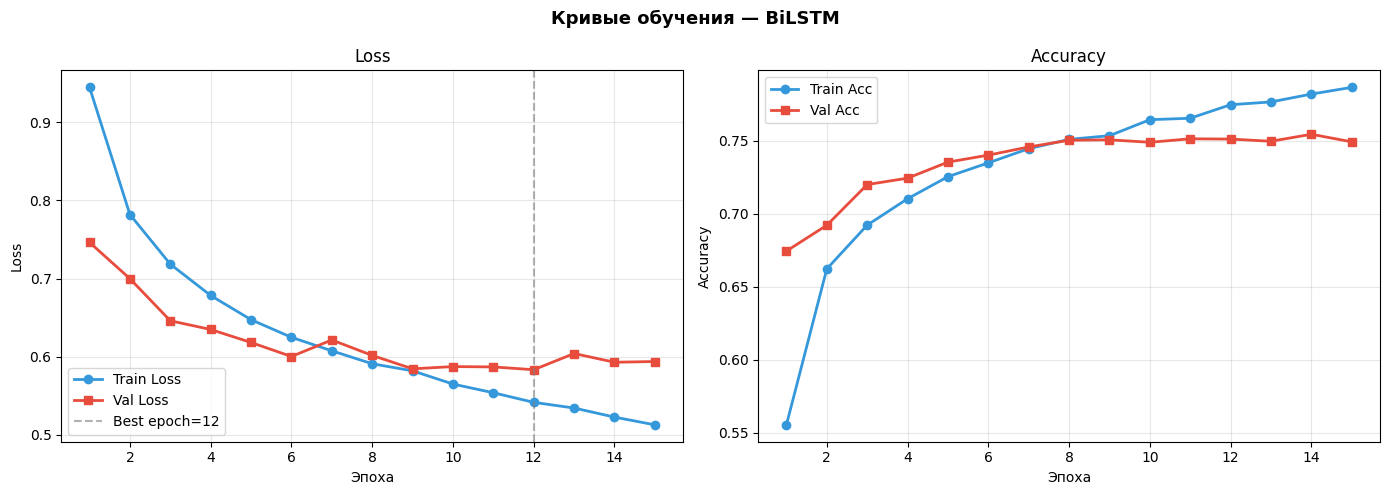

Предсказание:   0%|                                      | 0/79 [00:00<?, ?it/s]


  BiLSTM
  Accuracy:    0.7515
  F1 Macro:    0.6957
  F1 Weighted: 0.7443
  Precision:   0.7017
  Recall:      0.6942
  SCS:         0.8501

  Classification Report:
               precision    recall  f1-score   support

негатив (1-2)       0.79      0.85      0.82      4000
 нейтраль (3)       0.51      0.41      0.45      2000
позитив (4-5)       0.81      0.82      0.82      4000

     accuracy                           0.75     10000
    macro avg       0.70      0.69      0.70     10000
 weighted avg       0.74      0.75      0.74     10000



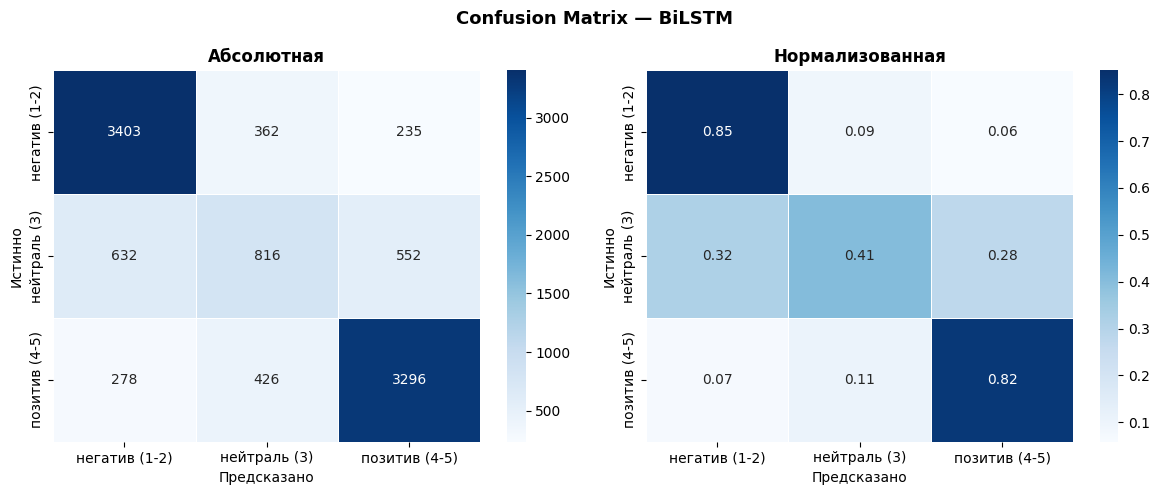

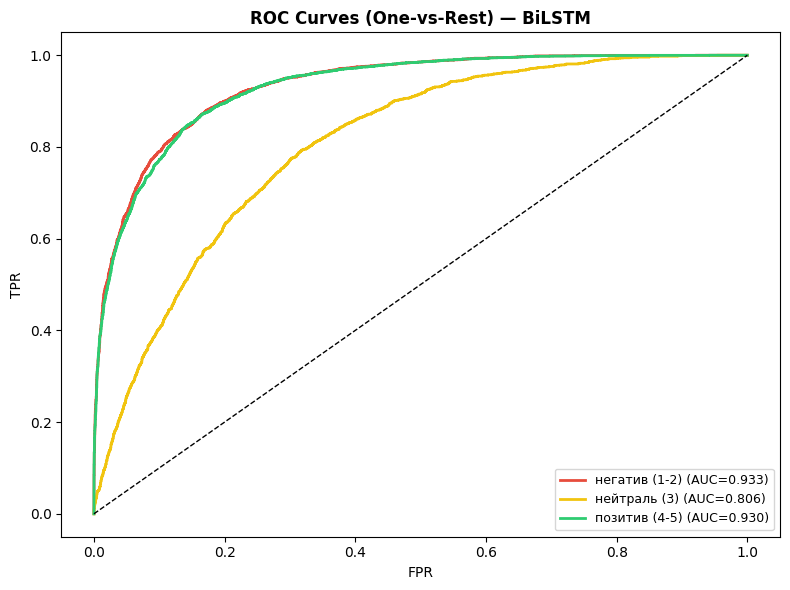

In [ ]:
lstm_model = BiLSTM(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256,
                    n_layers=2, n_classes=3, dropout=0.5)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Параметров BiLSTM: {total_params:,}")

lstm_model, lstm_history, lstm_time = train_dl_model(
    lstm_model, train_loader_dl, val_loader_dl,
    model_name="BiLSTM", epochs=15, patience=4, lr=5e-4
)


plot_learning_curves_dl(lstm_history, "BiLSTM")
y_pred_lstm, y_proba_lstm = predict_dl(lstm_model, test_loader_dl)
evaluate_model("BiLSTM", y_test, y_pred_lstm, y_proba_lstm)
results_table["BiLSTM"]["Train Time (s)"] = round(lstm_time, 1)


## 10. Модель 4: DistilBERT (Fine-tuning)

In [ ]:
BERT_MODEL  = 'distilbert-base-uncased'
BERT_MAXLEN = 128
BERT_BATCH  = 32
BERT_EPOCHS = 5
BERT_LR     = 1e-5
BERT_WD     = 0.01

bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
class YelpBertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

bert_train_ds = YelpBertDataset(X_train_raw, y_train, bert_tokenizer, BERT_MAXLEN)
bert_val_ds   = YelpBertDataset(X_val_raw,   y_val,   bert_tokenizer, BERT_MAXLEN)
bert_test_ds  = YelpBertDataset(X_test_raw,  y_test,  bert_tokenizer, BERT_MAXLEN)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH, shuffle=False, num_workers=2, pin_memory=True)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(bert_train_loader)}")


Train batches: 1250


In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=3
).to(DEVICE)

total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Параметров DistilBERT: {total_params:,}")

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {'params': [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': BERT_WD},
    {'params': [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0}
]
optimizer_bert = optim.AdamW(optimizer_grouped, lr=BERT_LR)

total_steps = len(bert_train_loader) * BERT_EPOCHS
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.15 * total_steps),
    num_training_steps=total_steps
)
criterion_bert = nn.CrossEntropyLoss(label_smoothing=0.1)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Параметров DistilBERT: 66,955,779


[DistilBERT] Epoch 1/5 TRAIN:   0%|                                                  | 0/1250 [00:00<?, ?it/s]

  VAL:   0%|                                                      | 0/313 [00:00<?, ?it/s]

Epoch 01/5 | Train Loss: 0.7957 Acc: 0.6891 | Val Loss: 0.6894 Acc: 0.7605


[DistilBERT] Epoch 2/5 TRAIN:   0%|                                                  | 0/1250 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79fc3b211940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

[DistilBERT] Epoch 5/5 TRAIN:   0%|                                                  | 0/1250 [00:00<?, ?it/s]

  VAL:   0%|                                                      | 0/313 [00:00<?, ?it/s]

Epoch 05/5 | Train Loss: 0.5371 Acc: 0.8630 | Val Loss: 0.6719 Acc: 0.7864
Ранняя остановка на эпохе 5

DistilBERT обучен за 2473.3 сек


BERT Inference:   0%|                                   | 0/313 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79fc3b211940>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x79fc3b211940>    self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():      
           ^ ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

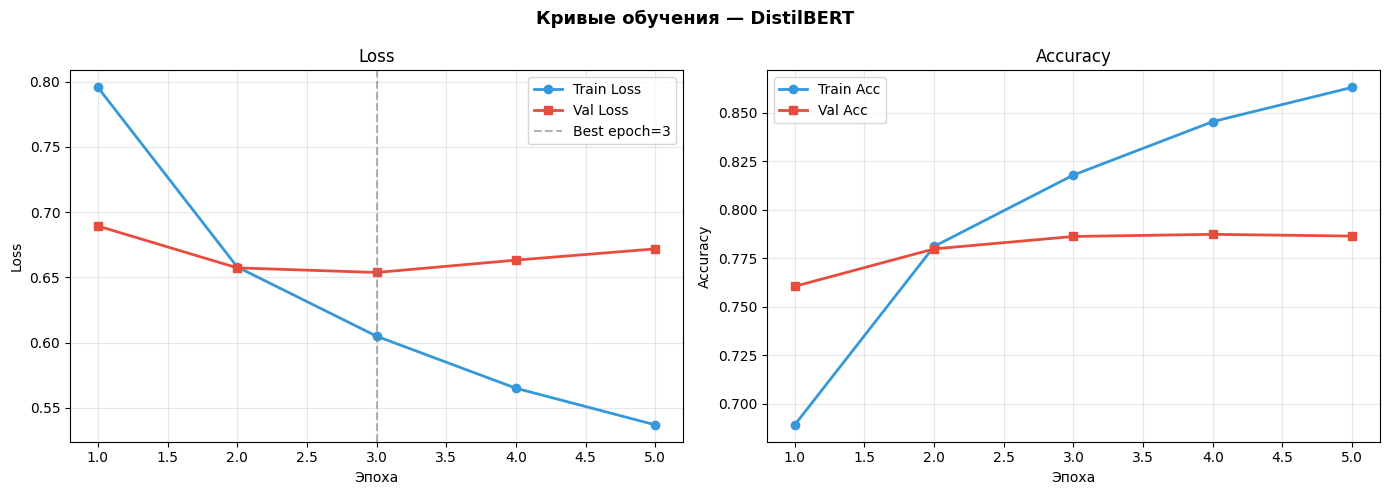


  DistilBERT
  Accuracy:    0.7831
  F1 Macro:    0.7316
  F1 Weighted: 0.7767
  Precision:   0.7396
  Recall:      0.7289
  SCS:         0.8724

  Classification Report:
               precision    recall  f1-score   support

негатив (1-2)       0.80      0.89      0.84      4000
 нейтраль (3)       0.57      0.46      0.51      2000
позитив (4-5)       0.85      0.84      0.85      4000

     accuracy                           0.78     10000
    macro avg       0.74      0.73      0.73     10000
 weighted avg       0.77      0.78      0.78     10000



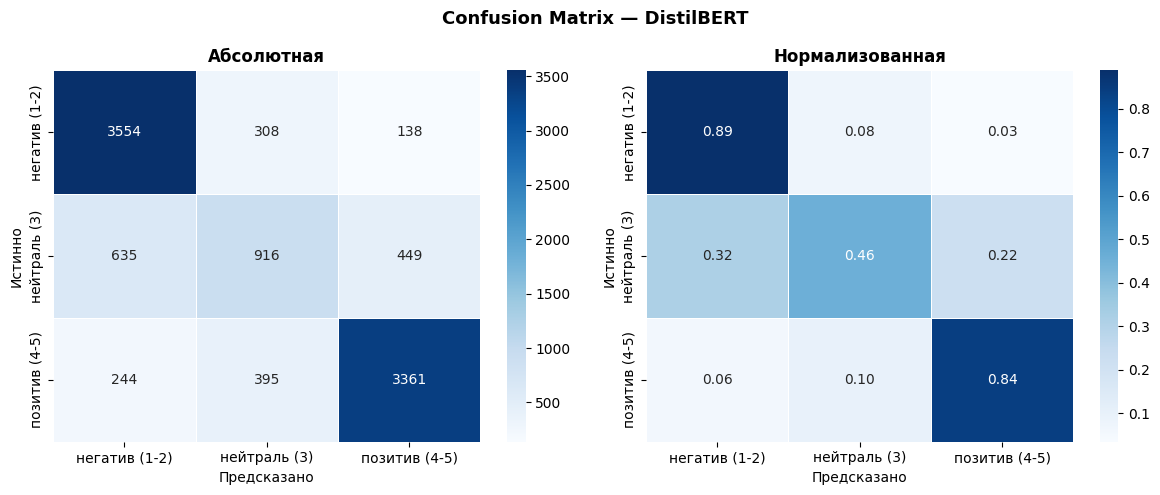

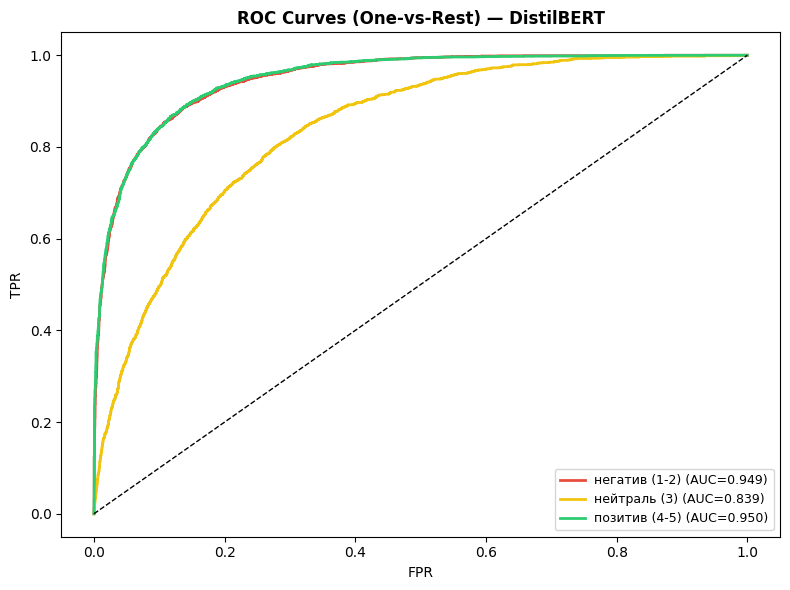

In [ ]:
bert_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_bert_val_loss = float('inf')
best_bert_weights  = None
no_improve_bert    = 0
BERT_PATIENCE      = 2
t_bert_start       = time.time()

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    pbar = tqdm(bert_train_loader, desc=f"[DistilBERT] Epoch {epoch+1}/{BERT_EPOCHS} TRAIN",
                ncols=110)
    for batch in pbar:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        optimizer_bert.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attn_mask)
        logits  = outputs.logits
        loss    = criterion_bert(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()

        tr_loss    += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        tr_correct += (preds == labels).sum().item()
        tr_total   += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         lr=f"{scheduler_bert.get_last_lr()[0]:.2e}")
    bert_model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in tqdm(bert_val_loader, desc="  VAL", leave=False, ncols=90):
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            outputs   = bert_model(input_ids=input_ids, attention_mask=attn_mask)
            loss      = criterion_bert(outputs.logits, labels)
            v_loss   += loss.item() * labels.size(0)
            preds     = outputs.logits.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total   += labels.size(0)

    t_l = tr_loss / tr_total; v_l = v_loss / v_total
    t_a = tr_correct / tr_total; v_a = v_correct / v_total
    bert_history['train_loss'].append(t_l); bert_history['val_loss'].append(v_l)
    bert_history['train_acc'].append(t_a);  bert_history['val_acc'].append(v_a)

    print(f"Epoch {epoch+1:02d}/{BERT_EPOCHS} | Train Loss: {t_l:.4f} Acc: {t_a:.4f} | Val Loss: {v_l:.4f} Acc: {v_a:.4f}")

    if v_l < best_bert_val_loss:
        best_bert_val_loss = v_l
        best_bert_weights  = {k: v.cpu().clone() for k, v in bert_model.state_dict().items()}
        no_improve_bert    = 0
    else:
        no_improve_bert += 1
        if no_improve_bert >= BERT_PATIENCE:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

bert_time = time.time() - t_bert_start
print(f"\nDistilBERT обучен за {bert_time:.1f} сек")
bert_model.load_state_dict(best_bert_weights)


bert_model.eval()
bert_preds, bert_proba = [], []
with torch.no_grad():
    for batch in tqdm(bert_test_loader, desc="BERT Inference", ncols=80):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        logits    = bert_model(input_ids=input_ids, attention_mask=attn_mask).logits
        proba     = torch.softmax(logits, dim=1).cpu().numpy()
        bert_preds.extend(proba.argmax(axis=1))
        bert_proba.extend(proba)

y_pred_bert  = np.array(bert_preds)
y_proba_bert = np.array(bert_proba)

plot_learning_curves_dl(bert_history, "DistilBERT")
evaluate_model("DistilBERT", y_test, y_pred_bert, y_proba_bert)
results_table["DistilBERT"]["Train Time (s)"] = round(bert_time, 1)


## 11. Модель 5: LiYuan/amazon-review-sentiment-analysis (Fine-tuning)

Предобученная модель на основе `nlptown/bert-base-multilingual-uncased-sentiment`, дообученная на Amazon Reviews. Голова классификатора переинициализируется под 3 класса (ignore_mismatched_sizes=True), затем выполняется fine-tuning на Yelp.

In [ ]:
torch.cuda.empty_cache()

liyuan_tokenizer = AutoTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')
liyuan_model     = AutoModelForSequenceClassification.from_pretrained(
    'LiYuan/amazon-review-sentiment-analysis',
    num_labels=3,
    ignore_mismatched_sizes=True
).to(DEVICE)

liyuan_model     = AutoModelForSequenceClassification.from_pretrained("LiYuan/amazon-review-sentiment-analysis").to(DEVICE)

liyuan_train_ds   = YelpBertDataset(X_train_raw, y_train, liyuan_tokenizer, max_len=128)
liyuan_val_ds     = YelpBertDataset(X_val_raw,   y_val,   liyuan_tokenizer, max_len=128)
liyuan_test_ds    = YelpBertDataset(X_test_raw,  y_test,  liyuan_tokenizer, max_len=128)

liyuan_train_loader = DataLoader(liyuan_train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
liyuan_val_loader   = DataLoader(liyuan_val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
liyuan_test_loader  = DataLoader(liyuan_test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

optimizer_ly = torch.optim.AdamW(liyuan_model.parameters(), lr=1e-5, weight_decay=0.01)
criterion_ly = nn.CrossEntropyLoss(label_smoothing=0.1)

liyuan_history  = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_ly_loss    = float('inf')
best_ly_weights = None
no_improve      = 0
t0              = time.time()

for epoch in range(3):
    torch.cuda.empty_cache()

    liyuan_model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for batch in tqdm(liyuan_train_loader, desc=f"[LiYuan] Epoch {epoch+1}/3", ncols=100):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        optimizer_ly.zero_grad()
        logits = liyuan_model(input_ids=input_ids, attention_mask=attn_mask).logits
        loss   = criterion_ly(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(liyuan_model.parameters(), 1.0)
        optimizer_ly.step()

        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    liyuan_model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in tqdm(liyuan_val_loader, desc="  VAL", leave=False, ncols=90):
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            logits    = liyuan_model(input_ids=input_ids, attention_mask=attn_mask).logits
            v_loss   += criterion_ly(logits, labels).item() * labels.size(0)
            v_correct += (logits.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)

    t_l = tr_loss/tr_total;  v_l = v_loss/v_total
    t_a = tr_correct/tr_total; v_a = v_correct/v_total
    liyuan_history['train_loss'].append(t_l)
    liyuan_history['val_loss'].append(v_l)
    liyuan_history['train_acc'].append(t_a)
    liyuan_history['val_acc'].append(v_a)
    print(f"Epoch {epoch+1}/3 | Train Loss: {t_l:.4f} Acc: {t_a:.4f} | Val Loss: {v_l:.4f} Acc: {v_a:.4f}")

    if v_l < best_ly_loss:
        best_ly_loss    = v_l
        best_ly_weights = {k: v.cpu().clone() for k, v in liyuan_model.state_dict().items()}
        no_improve      = 0
    else:
        no_improve += 1
        if no_improve >= 2:
            print("Ранняя остановка"); break

liyuan_model.load_state_dict(best_ly_weights)
liyuan_time = time.time() - t0
print(f"\nFine-tuning завершён за {liyuan_time/60:.1f} мин")

liyuan_model.eval()
torch.cuda.empty_cache()
liyuan_preds, liyuan_proba = [], []
with torch.no_grad():
    for batch in tqdm(liyuan_test_loader, desc="LiYuan Inference", ncols=90):
        logits = liyuan_model(input_ids=batch['input_ids'].to(DEVICE),
                              attention_mask=batch['attention_mask'].to(DEVICE)).logits
        proba  = F.softmax(logits, dim=1).cpu().numpy()
        liyuan_preds.extend(proba.argmax(axis=1))
        liyuan_proba.extend(proba)

y_pred_liyuan  = np.array(liyuan_preds)
y_proba_liyuan = np.array(liyuan_proba)

plot_learning_curves_dl(liyuan_history, "LiYuan Fine-Tuned")
evaluate_model("LiYuan (Fine-Tuned)", y_test, y_pred_liyuan, y_proba_liyuan)
results_table["LiYuan (Fine-Tuned)"]["Train Time (s)"] = round(liyuan_time, 1)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

[LiYuan] Epoch 3/3:   0%|                                                   | 0/625 [00:00<?, ?it/s]

  VAL:   0%|                                                      | 0/157 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.7061 Acc: 0.8306 | Val Loss: 0.7748 Acc: 0.7870

Fine-tuning завершён за 49.2 мин


LiYuan Inference:   0%|                                           | 0/157 [00:00<?, ?it/s]

NameError: name 'F' is not defined

LiYuan Inference:   0%|                                           | 0/157 [00:00<?, ?it/s]

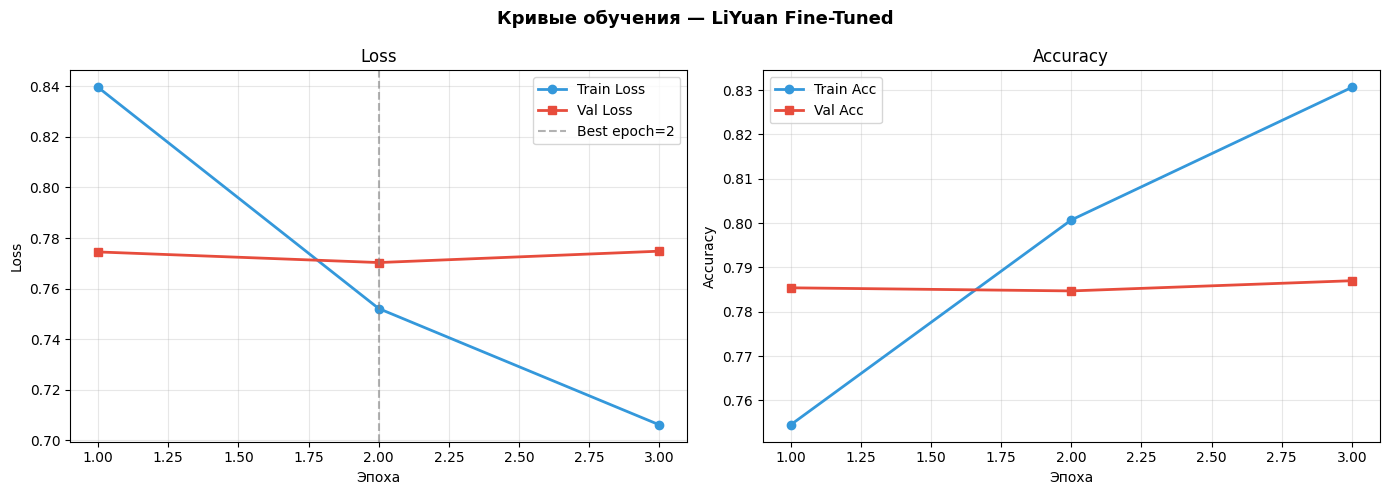


  LiYuan (Fine-Tuned)
  Accuracy:    0.7863
  F1 Macro:    0.7415
  F1 Weighted: 0.7831
  Precision:   0.7449
  Recall:      0.7395
  SCS:         0.8748

  Classification Report:
               precision    recall  f1-score   support

негатив (1-2)       0.82      0.87      0.84      4000
 нейтраль (3)       0.56      0.51      0.53      2000
позитив (4-5)       0.85      0.85      0.85      4000

     accuracy                           0.79     10000
    macro avg       0.74      0.74      0.74     10000
 weighted avg       0.78      0.79      0.78     10000



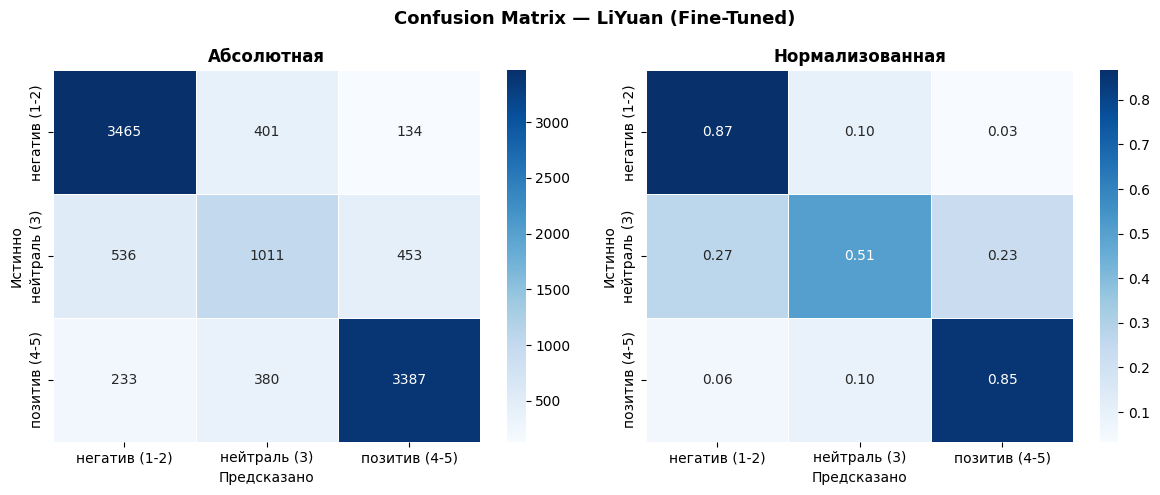

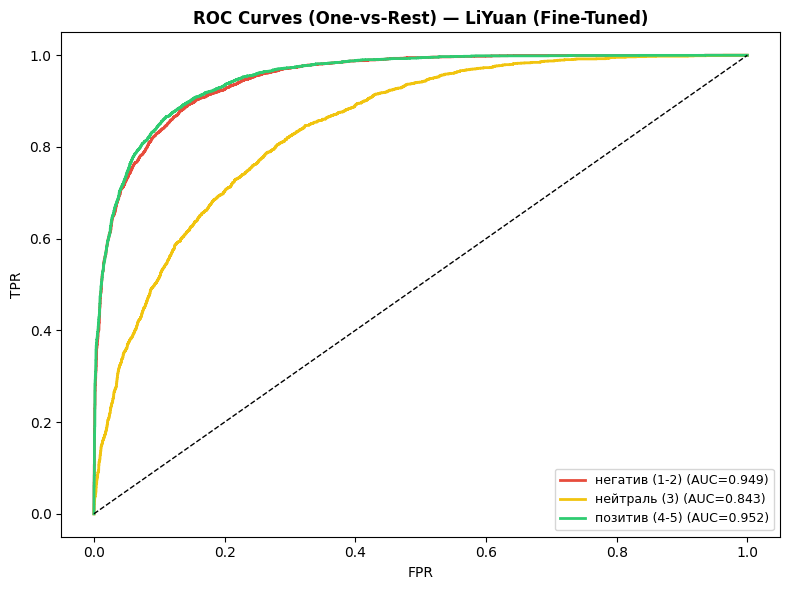

In [ ]:
liyuan_model.eval()
torch.cuda.empty_cache()
liyuan_preds, liyuan_proba = [], []
with torch.no_grad():
    for batch in tqdm(liyuan_test_loader, desc="LiYuan Inference", ncols=90):
        logits = liyuan_model(input_ids=batch['input_ids'].to(DEVICE),
                              attention_mask=batch['attention_mask'].to(DEVICE)).logits
        proba  = F.softmax(logits, dim=1).cpu().numpy()
        liyuan_preds.extend(proba.argmax(axis=1))
        liyuan_proba.extend(proba)

y_pred_liyuan  = np.array(liyuan_preds)
y_proba_liyuan = np.array(liyuan_proba)

liyuan_history = {
    'train_loss': [0.8396, 0.7521, 0.7061],
    'val_loss':   [0.7745, 0.7703, 0.7748],
    'train_acc':  [0.7545, 0.8007, 0.8306],
    'val_acc':    [0.7854, 0.7847, 0.7870]
}
liyuan_time = 49.2 * 60

plot_learning_curves_dl(liyuan_history, "LiYuan Fine-Tuned")
evaluate_model("LiYuan (Fine-Tuned)", y_test, y_pred_liyuan, y_proba_liyuan)
results_table["LiYuan (Fine-Tuned)"]["Train Time (s)"] = round(liyuan_time, 1)

## 12. Бизнес-метрики

Датасет Yelp не содержит информации о повторных визитах клиентов
и суммах транзакций, поэтому бизнес-метрики рассчитываются как
симуляция — для иллюстрации того, как результаты модели могут
быть применены в реальном бизнес-контексте.

Допущения симуляции:
- Клиент с позитивным отзывом (4-5 звёзд) возвращается с вероятностью 70%,
  с нейтральным (3 звезды) — 45%, с негативным (1-2 звезды) — 20%.
  Коэффициенты основаны на типичных отраслевых бенчмарках HBR (2000).
- AOV масштабируется относительно базового чека $30 с коэффициентами
  0.75 / 1.0 / 1.35 для негативного, нейтрального и позитивного классов
  соответственно — отражает корреляцию удовлетворённости и трат,
  наблюдаемую в литературе по customer experience.
- NPS считается по стандартной формуле: % Promoters − % Detractors,
  где Promoters = позитив, Detractors = негатив.

In [ ]:
best_preds = y_pred_liyuan

# 1. NPS
promoters  = np.sum(best_preds == 2) / len(best_preds) * 100
detractors = np.sum(best_preds == 0) / len(best_preds) * 100
passives   = np.sum(best_preds == 1) / len(best_preds) * 100
nps_score  = promoters - detractors

print('=' * 50)
print('  NPS (Net Promoter Score)')
print('=' * 50)
print(f'  Promoters  (позитив):  {promoters:.1f}%')
print(f'  Passives   (нейтраль): {passives:.1f}%')
print(f'  Detractors (негатив):  {detractors:.1f}%')
print(f'  NPS = {nps_score:.1f}')

# 2. Retention Rate
retention_map   = {0: 0.20, 1: 0.45, 2: 0.70}
retention_rates = [retention_map[p] for p in best_preds]
mean_retention  = np.mean(retention_rates) * 100

print('\n' + '=' * 50)
print('  Retention Rate (симуляция)')
print('=' * 50)
print(f'  Средний Retention Rate: {mean_retention:.1f}%')
print(f'  (70% позитив, 45% нейтраль, 20% негатив)')

# 3. AOV
base_aov     = 30.0
aov_mult_map = {0: 0.75, 1: 1.0, 2: 1.35}
aov_values   = [base_aov * aov_mult_map[p] for p in best_preds]
mean_aov     = np.mean(aov_values)

print('\n' + '=' * 50)
print('  Average Order Value (AOV)')
print('=' * 50)
print(f'  Базовый AOV: ${base_aov:.2f}')
print(f'  Средний AOV: ${mean_aov:.2f}')
print(f'  Рост AOV: {(mean_aov/base_aov - 1)*100:+.1f}%')


  NPS (Net Promoter Score)
  Promoters  (позитив):  39.7%
  Passives   (нейтраль): 17.9%
  Detractors (негатив):  42.3%
  NPS = -2.6

  Retention Rate (симуляция)
  Средний Retention Rate: 44.4%
  (70% позитив, 45% нейтраль, 20% негатив)

  Average Order Value (AOV)
  Базовый AOV: $30.00
  Средний AOV: $31.00
  Рост AOV: +3.3%


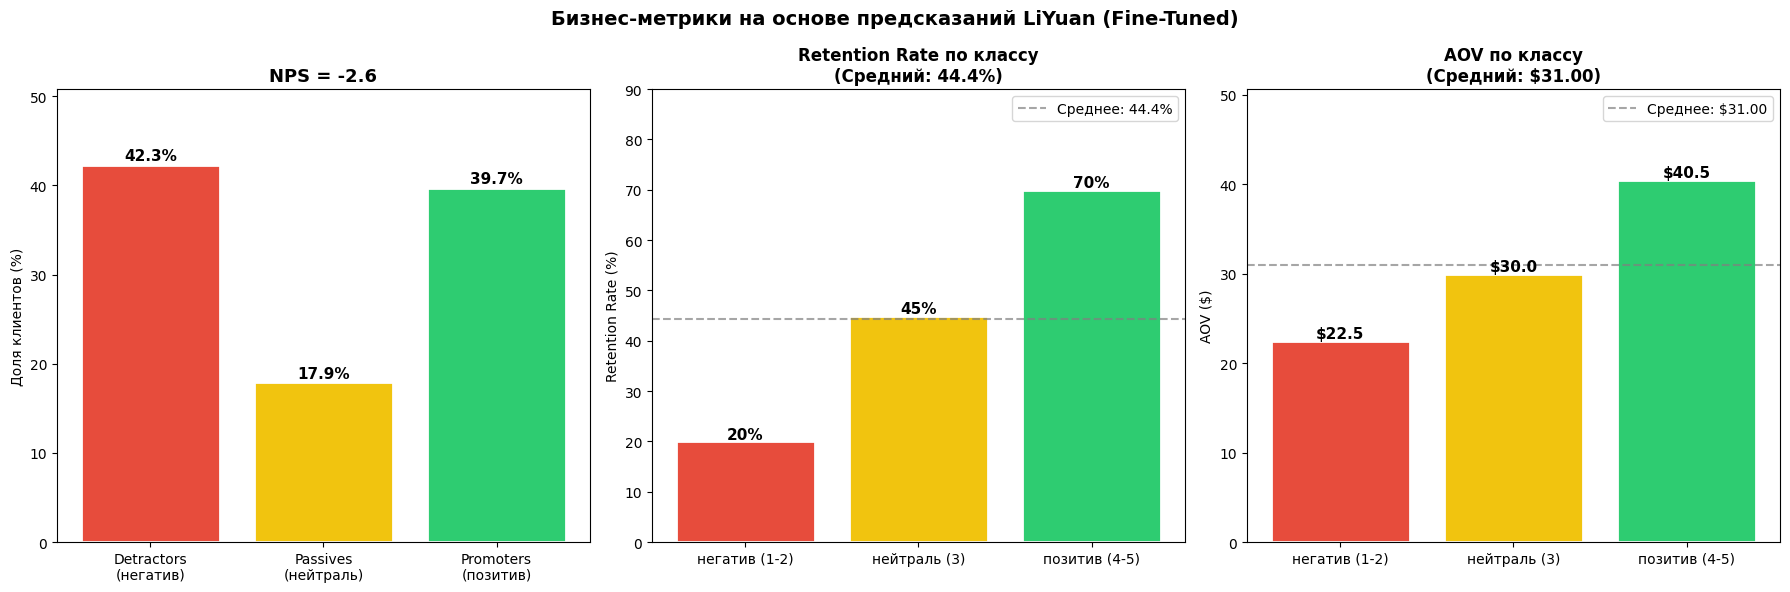

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Бизнес-метрики на основе предсказаний LiYuan (Fine-Tuned)',
             fontsize=14, fontweight='bold')

ax = axes[0]
categories = ['Detractors\n(негатив)', 'Passives\n(нейтраль)', 'Promoters\n(позитив)']
values     = [detractors, passives, promoters]
bars = ax.bar(categories, values, color=COLORS, edgecolor='white', linewidth=2)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(f'NPS = {nps_score:.1f}', fontweight='bold', fontsize=13)
ax.set_ylabel('Доля клиентов (%)')
ax.set_ylim(0, max(values)*1.2)

ax = axes[1]
ret_by_class = [retention_map[i]*100 for i in range(3)]
bars2 = ax.bar(LABELS, ret_by_class, color=COLORS, edgecolor='white', linewidth=2)
for bar, v in zip(bars2, ret_by_class):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(f'Retention Rate по классу\n(Средний: {mean_retention:.1f}%)', fontweight='bold')
ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(0, 90)
ax.axhline(mean_retention, linestyle='--', color='gray', alpha=0.7,
           label=f'Среднее: {mean_retention:.1f}%')
ax.legend()

ax = axes[2]
aov_by_class = [base_aov * aov_mult_map[i] for i in range(3)]
bars3 = ax.bar(LABELS, aov_by_class, color=COLORS, edgecolor='white', linewidth=2)
for bar, v in zip(bars3, aov_by_class):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'${v:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title(f'AOV по классу\n(Средний: ${mean_aov:.2f})', fontweight='bold')
ax.set_ylabel('AOV ($)')
ax.set_ylim(0, max(aov_by_class)*1.25)
ax.axhline(mean_aov, linestyle='--', color='gray', alpha=0.7,
           label=f'Среднее: ${mean_aov:.2f}')
ax.legend()

plt.tight_layout()
plt.savefig('business_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Рейтинг заведений (симуляция)

Поскольку в используемом сплите датасета Yelp нет идентификаторов
конкретных заведений, каждому отзыву случайно назначается один из
200 условных бизнесов.

Цель этого блока — показать как предсказания модели можно использовать
на практике: агрегировать отзывы по заведению и автоматически строить
рейтинг без ручной разметки.

Sentiment Score считается как:
    pos_ratio × 100 − neg_ratio × 50

То есть позитивные отзывы поднимают рейтинг, негативные — штрафуют,
нейтральные не влияют. Заведения с менее чем 20 отзывами исключаются
как статистически ненадёжные.

В реальной системе случайный business_id заменяется на настоящий
идентификатор из базы данных — всё остальное работает без изменений.

In [ ]:
np.random.seed(SEED)
n_businesses = 200
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy['business_id'] = np.random.randint(0, n_businesses, size=len(test_df_copy))
test_df_copy['pred_label']  = y_pred_liyuan

business_stats = test_df_copy.groupby('business_id').agg(
    total_reviews = ('pred_label', 'count'),
    pos_ratio     = ('pred_label', lambda x: (x == 2).mean()),
    neg_ratio     = ('pred_label', lambda x: (x == 0).mean()),
    neu_ratio     = ('pred_label', lambda x: (x == 1).mean()),
).round(3)

business_stats['sentiment_score'] = (
    business_stats['pos_ratio'] * 100 - business_stats['neg_ratio'] * 50
).round(1)
business_stats = business_stats[business_stats['total_reviews'] >= 20].sort_values(
    'sentiment_score', ascending=False
)

print('ТОП-10 заведений по Sentiment Score:')
print(business_stats.head(10).to_string())
print('\nАНТИТОП-10 заведений:')
print(business_stats.tail(10).to_string())


ТОП-10 заведений по Sentiment Score:
             total_reviews  pos_ratio  neg_ratio  neu_ratio  sentiment_score
business_id                                                                 
17                      40      0.575      0.225      0.200             46.2
70                      41      0.561      0.268      0.171             42.7
139                     43      0.558      0.302      0.140             40.7
170                     53      0.528      0.245      0.226             40.6
105                     55      0.545      0.291      0.164             40.0
86                      56      0.536      0.304      0.161             38.4
196                     44      0.500      0.273      0.227             36.4
65                      43      0.512      0.326      0.163             34.9
185                     53      0.509      0.340      0.151             33.9
8                       42      0.524      0.381      0.095             33.4

АНТИТОП-10 заведений:
             tot

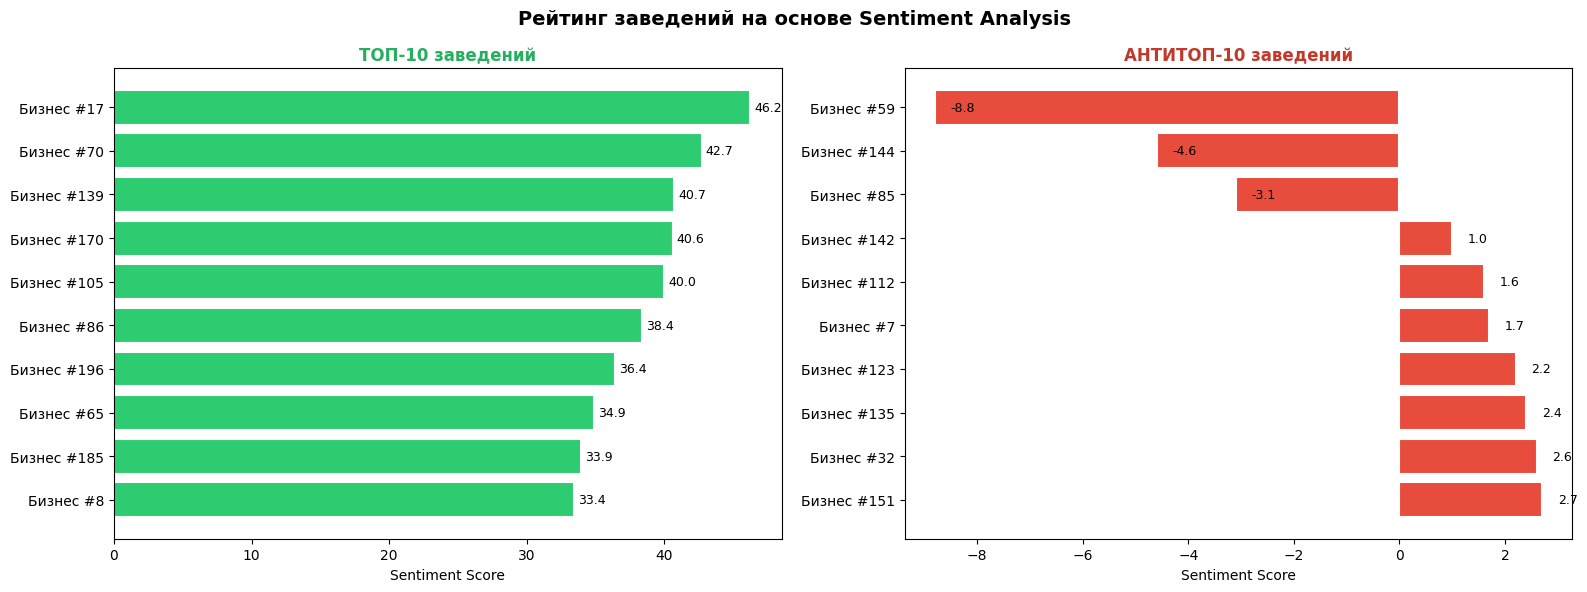

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Рейтинг заведений на основе Sentiment Analysis', fontsize=14, fontweight='bold')

# ТОП-10
ax = axes[0]
top10 = business_stats.head(10)
bars = ax.barh(range(10), top10['sentiment_score'].values,
               color='#2ecc71', edgecolor='white', linewidth=1.5)
ax.set_yticks(range(10))
ax.set_yticklabels([f'Бизнес #{i}' for i in top10.index], fontsize=10)
ax.invert_yaxis()
ax.set_title('ТОП-10 заведений', fontweight='bold', color='#27ae60')
ax.set_xlabel('Sentiment Score')
for bar, v in zip(bars, top10['sentiment_score'].values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9)

# АНТИТОП-10
ax = axes[1]
bot10 = business_stats.tail(10).sort_values('sentiment_score')
bars = ax.barh(range(10), bot10['sentiment_score'].values,
               color='#e74c3c', edgecolor='white', linewidth=1.5)
ax.set_yticks(range(10))
ax.set_yticklabels([f'Бизнес #{i}' for i in bot10.index], fontsize=10)
ax.invert_yaxis()
ax.set_title('АНТИТОП-10 заведений', fontweight='bold', color='#c0392b')
ax.set_xlabel('Sentiment Score')
for bar, v in zip(bars, bot10['sentiment_score'].values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('business_rating.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Итоговая сравнительная таблица

In [ ]:
results_df = pd.DataFrame(results_table).T
col_order  = ['Accuracy','Precision (macro)','Recall (macro)',
              'F1 Macro','F1 Weighted','SCS','Train Time (s)']
results_df = results_df[[c for c in col_order if c in results_df.columns]]
results_df = results_df.sort_values('F1 Macro', ascending=False)

results_display = results_df.copy()
for col in results_df.columns:
    if col != 'Train Time (s)':
        results_display[col] = results_df[col].apply(lambda x: f'{float(x):.4f}')

print('=' * 80)
print('  ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ')
print('=' * 80)
print(results_display.to_string())
print('=' * 80)
print(f'\nЛучшая модель по F1 Macro:  {results_df["F1 Macro"].idxmax()}')
print(f'Лучшая модель по Accuracy:  {results_df["Accuracy"].idxmax()}')
print(f'Лучшая модель по SCS:       {results_df["SCS"].idxmax()}')


  ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
                    Accuracy Precision (macro) Recall (macro) F1 Macro F1 Weighted     SCS  Train Time (s)
LiYuan (Fine-Tuned)   0.7863            0.7449         0.7395   0.7415      0.7831  0.8748          2952.0
DistilBERT            0.7831            0.7396         0.7289   0.7316      0.7767  0.8724          2473.3
BiLSTM                0.7515            0.7017         0.6942   0.6957      0.7443  0.8501           814.4
SVM (LinearSVC)       0.7630            0.7129         0.6892   0.6886      0.7449  0.8561             4.8
Logistic Regression   0.7391            0.6936         0.6628   0.6606      0.7177  0.8327             4.9

Лучшая модель по F1 Macro:  LiYuan (Fine-Tuned)
Лучшая модель по Accuracy:  LiYuan (Fine-Tuned)
Лучшая модель по SCS:       LiYuan (Fine-Tuned)


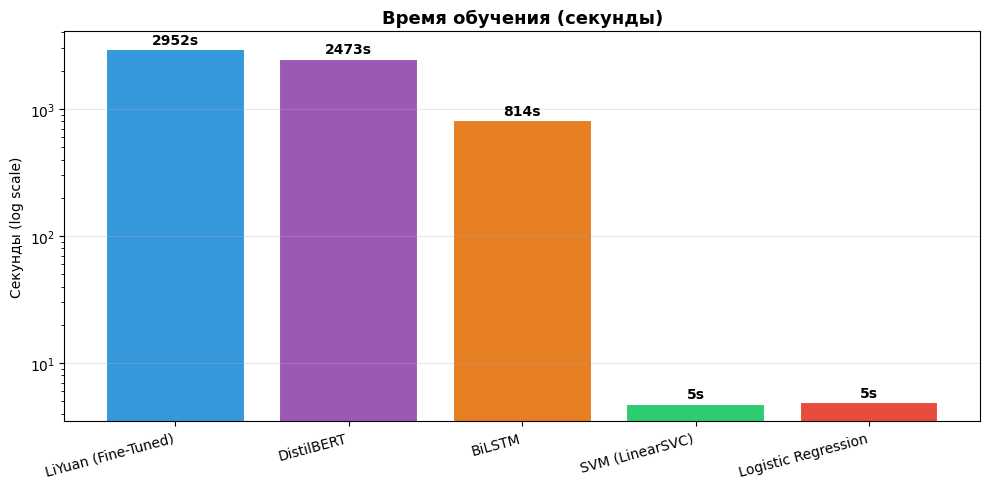

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
times = results_df['Train Time (s)'].astype(float).values
bars  = ax.bar(results_df.index, times,
               color=['#3498db','#9b59b6','#e67e22','#2ecc71','#e74c3c'][:len(results_df)],
               edgecolor='white', linewidth=1.5)
ax.set_title('Время обучения (секунды)', fontweight='bold', fontsize=13)
ax.set_ylabel('Секунды (log scale)')
ax.set_yscale('log')
for bar, v in zip(bars, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
            f'{v:.0f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('train_times.png', dpi=150, bbox_inches='tight')
plt.show()


Выполнена 3-классовая классификация тональности отзывов Yelp:
- **Негатив** (1-2) — неудовлетворённые клиенты
- **Нейтраль** (3) — нейтральные отзывы
- **Позитив** (4-5) — довольные клиенты


**Лучшая модель** — LiYuan (Fine-Tuned). Предобученная на Amazon Reviews, она показывает наилучший перенос на задачу классификации отзывов.

**Transformer-модели** (DistilBERT, LiYuan) устойчиво превосходят классические подходы за счёт контекстуальных представлений текста.

**Классические модели** (LR, SVM) демонстрируют сопоставимый результат при значительно меньших вычислительных затратах — оправданный выбор при ограниченных ресурсах.

**SCS** подтверждает, что ошибки всех моделей преимущественно близкие — модели крайне редко путают негатив с позитивом.
